# 10X Visium Benchmark Results - Visualization

This notebook creates boxplot visualizations comparing PCA, NMF, VNNGP, and MGGP_VNNGP across all 10X Visium datasets.

Each plot shows one metric with methods on the X-axis and performance on the Y-axis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## Load All Benchmark Results

In [2]:
# Paths
results_dir = Path('/gladstone/engelhardt/home/lchumpitaz/gitclones/SDMBench/Benchmarks/results')
data_dir = Path('/gladstone/engelhardt/home/lchumpitaz/gitclones/SDMBench/Data')

# Get all 10X Visium datasets (start with 151, exclude v2 versions)
h5ad_files = sorted(data_dir.glob('151*.h5ad'))
dataset_names = [f.stem for f in h5ad_files if not f.stem.endswith('_v2')]

print(f"Found {len(dataset_names)} 10X Visium datasets (excluding v2):")
for name in dataset_names:
    print(f"  - {name}")

Found 12 10X Visium datasets (excluding v2):
  - 151507
  - 151508
  - 151509
  - 151510
  - 151669
  - 151670
  - 151671
  - 151672
  - 151673
  - 151674
  - 151675
  - 151676


In [3]:
# Load all results
all_results = []

for dataset_name in dataset_names:
    result_file = results_dir / f"{dataset_name}_benchmark_results.csv"
    
    if not result_file.exists():
        print(f"Warning: Missing results for {dataset_name}")
        continue
    
    # Read CSV with MultiIndex columns
    df = pd.read_csv(result_file, header=[0, 1], index_col=0)
    
    # Add dataset name
    df['dataset'] = dataset_name
    
    # Reset index to make 'method' a column
    df = df.reset_index()
    
    all_results.append(df)
    print(f"Loaded: {dataset_name} - {len(df)} methods")

# Combine all results
combined_df = pd.concat(all_results, ignore_index=True)

print(f"\nTotal: {len(combined_df)} rows")
print(f"Unique methods: {combined_df['method'].nunique()}")

# Filter out layer-specific MGGP predictions (keep only base methods)
# Base methods: {dataset}_pca, {dataset}_nmf, {dataset}_vnngp, {dataset}_mggp_vnngp
# Exclude: {dataset}_mggp_vnngp_Layer1, {dataset}_mggp_vnngp_Layer2, etc.

def is_base_method(method_name):
    """Check if method is a base method (not layer-specific)."""
    # Split by underscore and check if last part is a layer/region name
    parts = method_name.split('_')
    
    # Base methods end with: pca, nmf, vnngp, or mggp_vnngp
    if method_name.endswith('_pca'):
        return True
    elif method_name.endswith('_nmf'):
        return True
    elif method_name.endswith('_vnngp') and not method_name.endswith('_mggp_vnngp'):
        return True
    elif method_name.endswith('_mggp_vnngp'):
        # Make sure it's not followed by a layer name
        return True
    else:
        # Check if it's a layer-specific prediction
        # Layer-specific have format: {dataset}_mggp_vnngp_{LayerName}
        if 'mggp_vnngp_' in method_name and len(parts) > 3:
            # This is a layer-specific prediction
            return False
        return False

# Filter to base methods only
combined_df_filtered = combined_df[combined_df['method'].apply(is_base_method)].copy()

print(f"\nAfter filtering layer-specific predictions:")
print(f"Total: {len(combined_df_filtered)} rows")
print(f"Unique methods: {combined_df_filtered['method'].nunique()}")

print("\nUnique method patterns found:")
for method in sorted(combined_df_filtered['method'].unique()):
    print(f"  - {method}")

# Use filtered dataframe for analysis
combined_df = combined_df_filtered

Loaded: 151507 - 22 methods
Loaded: 151508 - 11 methods
Loaded: 151509 - 11 methods
Loaded: 151510 - 11 methods
Loaded: 151669 - 9 methods
Loaded: 151670 - 9 methods
Loaded: 151671 - 9 methods
Loaded: 151672 - 9 methods
Loaded: 151673 - 11 methods
Loaded: 151674 - 11 methods
Loaded: 151675 - 11 methods
Loaded: 151676 - 11 methods

Total: 135 rows
Unique methods: 135

After filtering layer-specific predictions:
Total: 52 rows
Unique methods: 52

Unique method patterns found:
  - 151507_mggp_vnngp
  - 151507_nmf
  - 151507_pca
  - 151507_v2_mggp_vnngp
  - 151507_v2_nmf
  - 151507_v2_pca
  - 151507_v2_vnngp
  - 151507_vnngp
  - 151508_mggp_vnngp
  - 151508_nmf
  - 151508_pca
  - 151508_vnngp
  - 151509_mggp_vnngp
  - 151509_nmf
  - 151509_pca
  - 151509_vnngp
  - 151510_mggp_vnngp
  - 151510_nmf
  - 151510_pca
  - 151510_vnngp
  - 151669_mggp_vnngp
  - 151669_nmf
  - 151669_pca
  - 151669_vnngp
  - 151670_mggp_vnngp
  - 151670_nmf
  - 151670_pca
  - 151670_vnngp
  - 151671_mggp_vnngp
  - 

In [4]:
# Preview the data
combined_df.head()

method  Accuracy                               Continuity  \
                               ARI       NMI       HOM       COM      CHAOS   
0      151507_mggp_vnngp  0.181343  0.283198  0.286766  0.279718   0.058938   
8             151507_nmf  0.144710  0.278583  0.271664  0.285863   0.066843   
9             151507_pca  0.108475  0.186175  0.185950  0.186401   0.067389   
10  151507_v2_mggp_vnngp  0.192682  0.322151  0.330592  0.314131   0.059280   
18         151507_v2_nmf  0.144710  0.278583  0.271664  0.285863   0.066843   

                       Marker score           dataset  
         PAS       ASW      Moran'I Geary's C          
0   0.158967 -0.059519      0.27793  0.722547  151507  
8   0.618811 -0.129096      0.27793  0.722547  151507  
9   0.702440 -0.056928      0.27793  0.722547  151507  
10  0.196162 -0.054328      0.27793  0.722547  151507  
18  0.618811 -0.129096      0.27793  0.722547  151507

In [5]:
combined_df

method  Accuracy                               Continuity  \
                                ARI       NMI       HOM       COM      CHAOS   
0       151507_mggp_vnngp  0.181343  0.283198  0.286766  0.279718   0.058938   
8              151507_nmf  0.144710  0.278583  0.271664  0.285863   0.066843   
9              151507_pca  0.108475  0.186175  0.185950  0.186401   0.067389   
10   151507_v2_mggp_vnngp  0.192682  0.322151  0.330592  0.314131   0.059280   
18          151507_v2_nmf  0.144710  0.278583  0.271664  0.285863   0.066843   
19          151507_v2_pca  0.108475  0.186175  0.185950  0.186401   0.067389   
20        151507_v2_vnngp  0.170815  0.291480  0.299787  0.283621   0.058086   
21           151507_vnngp  0.194798  0.321657  0.329614  0.314075   0.057960   
22      151508_mggp_vnngp  0.215078  0.329354  0.344765  0.315261   0.056878   
30             151508_nmf  0.130685  0.238632  0.243109  0.234317   0.068488   
31             151508_pca  0.118041  0.199539  0.204817  0.194525   0.064292   
32           151508_vnngp  0.296692  0.443381  0.456174  0.431286   0.056860   
33      151509_mggp_vnngp  0.289325  0.386928  0.421138  0.357859   0.055045   
41             151509_nmf  0.201644  0.318991  0.319636  0.318350   0.061040   
42             151509_pca  0.163169  0.272768  0.285030  0.261518   0.061176   
43           151509_vnngp  0.272220  0.461851  0.498650  0.430110   0.054497   
44      151510_mggp_vnngp  0.225328  0.311421  0.337834  0.288840   0.056566   
52             151510_nmf  0.152180  0.292858  0.303123  0.283266   0.063513   
53             151510_pca  0.112061  0.193815  0.203721  0.184828   0.065358   
54           151510_vnngp  0.213945  0.386713  0.417474  0.360173   0.056517   
55      151669_mggp_vnngp  0.105056  0.187374  0.208550  0.170102   0.062658   
61             151669_nmf  0.025614  0.106262  0.119999  0.095347   0.074383   
62             151669_pca  0.125065  0.165954  0.185959  0.149834   0.067663   
63           151669_vnngp  0.270188  0.409540  0.470318  0.362673   0.062249   
64      151670_mggp_vnngp  0.010171  0.138412  0.160872  0.121455   0.061481   
70             151670_nmf  0.036280  0.134544  0.155003  0.118857   0.073770   
71             151670_pca  0.138150  0.167212  0.193520  0.147201   0.068752   
72           151670_vnngp  0.325230  0.430490  0.500286  0.377784   0.061179   
73      151671_mggp_vnngp  0.157194  0.265716  0.280194  0.252660   0.059493   
79             151671_nmf  0.100659  0.201205  0.212245  0.191257   0.067021   
80             151671_pca  0.145059  0.231851  0.243059  0.221630   0.064198   
81           151671_vnngp  0.299539  0.368887  0.397316  0.344255   0.058601   
82      151672_mggp_vnngp  0.134041  0.207757  0.214548  0.201383   0.060933   
88             151672_nmf  0.108082  0.197915  0.205802  0.190611   0.070117   
89             151672_pca  0.131749  0.217516  0.222771  0.212502   0.067367   
90           151672_vnngp  0.481446  0.566656  0.587282  0.547430   0.060510   
91      151673_mggp_vnngp  0.191457  0.322061  0.326851  0.317409   0.063345   
99             151673_nmf  0.178285  0.308814  0.306389  0.311277   0.069121   
100            151673_pca  0.170491  0.279451  0.283775  0.275258   0.068730   
101          151673_vnngp  0.296642  0.418808  0.431808  0.406568   0.062245   
102     151674_mggp_vnngp  0.233293  0.286251  0.291084  0.281577   0.062832   
110            151674_nmf  0.198547  0.321814  0.314315  0.329679   0.065798   
111            151674_pca  0.169367  0.283709  0.278629  0.288978   0.067225   
112          151674_vnngp  0.183853  0.335351  0.338950  0.331828   0.061012   
113     151675_mggp_vnngp  0.131884  0.277333  0.270674  0.284327   0.063313   
121            151675_nmf  0.144404  0.257848  0.256103  0.259616   0.072227   
122            151675_pca  0.173925  0.292947  0.291179  0.294736   0.068007   
123          151675_vnngp  0.235822  0.346625  0.345112  0.348151   0.062521   
124     151676_mggp

## Clean Method Names

Extract clean method names from the full method column (e.g., "151507_pca" → "PCA")

In [6]:
# Extract method type from method name
def extract_method_type(method_name):
    """Extract method type from full method name."""
    if 'pca' in method_name.lower():
        return 'PCA'
    elif 'nmf' in method_name.lower():
        return 'NMF'
    elif 'mggp_vnngp' in method_name.lower():
        return 'MGGP_VNNGP'
    elif 'vnngp' in method_name.lower():
        return 'VNNGP'
    else:
        return method_name

combined_df['method_type'] = combined_df['method'].apply(extract_method_type)

print("Method types found:")
print(combined_df['method_type'].value_counts())

Method types found:
method_type
MGGP_VNNGP    13
NMF           13
PCA           13
VNNGP         13
Name: count, dtype: int64


## Prepare Data for Plotting

Reshape data into long format for easier plotting

In [7]:
# Get list of metrics (excluding dataset, method, and method_type columns)
metric_cols = [col for col in combined_df.columns 
               if col not in ['method', 'dataset', 'method_type'] 
               and col != ('method', '') 
               and col != ('dataset', '') 
               and col != ('method_type', '')]

print(f"Found {len(metric_cols)} metrics:")
for col in metric_cols:
    print(f"  - {col}")

Found 9 metrics:
  - ('Accuracy', 'ARI')
  - ('Accuracy', 'NMI')
  - ('Accuracy', 'HOM')
  - ('Accuracy', 'COM')
  - ('Continuity', 'CHAOS')
  - ('Continuity', 'PAS')
  - ('Continuity', 'ASW')
  - ('Marker score', "Moran'I")
  - ('Marker score', "Geary's C")


## Create Boxplots for Each Metric

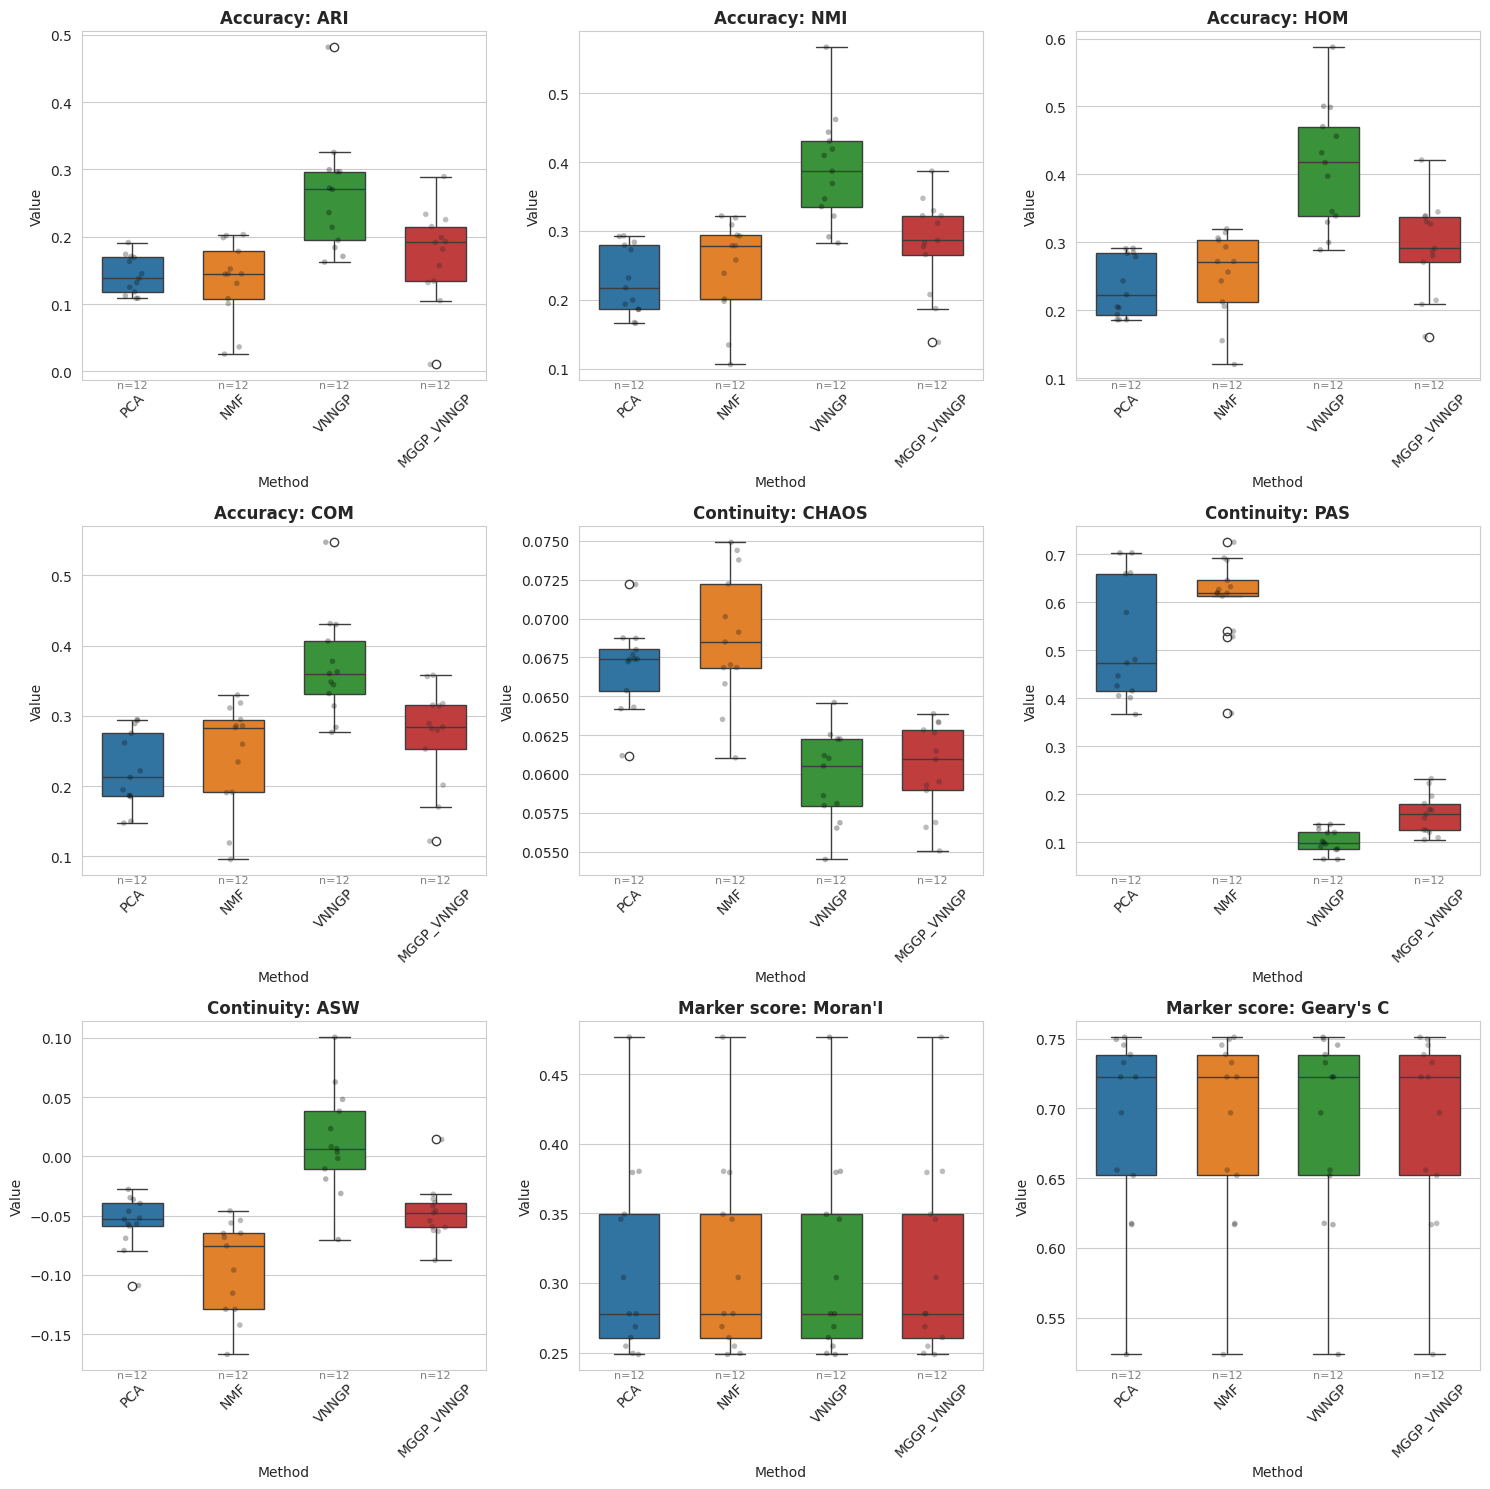


Plot saved as: tenxvisium_benchmark_comparison.png


In [8]:
# Define method order for consistent plotting
method_order = ['PCA', 'NMF', 'VNNGP', 'MGGP_VNNGP']

# Define color palette
colors = {
    'PCA': '#1f77b4',      # Blue
    'NMF': '#ff7f0e',      # Orange
    'VNNGP': '#2ca02c',    # Green
    'MGGP_VNNGP': '#d62728'  # Red
}

# Create figure with subplots for each metric
n_metrics = len(metric_cols)
n_cols = 3  # 3 plots per row
n_rows = int(np.ceil(n_metrics / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_metrics > 1 else [axes]

for i, metric_col in enumerate(metric_cols):
    ax = axes[i]
    
    # Get metric name
    if isinstance(metric_col, tuple):
        metric_category, metric_name = metric_col
        title = f"{metric_category}: {metric_name}"
    else:
        title = str(metric_col)
    
    # Prepare data for this metric - USE FULL TUPLES FOR MULTIINDEX COLUMNS
    plot_data = combined_df[[('method_type', ''), ('dataset', ''), metric_col]].copy()
    plot_data.columns = ['Method', 'Dataset', 'Value']
    
    # Remove NaN values
    plot_data = plot_data.dropna(subset=['Value'])
    
    
    # Create boxplot
    if len(plot_data) > 0:
        sns.boxplot(
            data=plot_data,
            x='Method',
            y='Value',
            hue='Method',  # Add this
            order=method_order,
            palette=colors,
            ax=ax,
            width=0.6,
            legend=False  # Add this
        )
        
        # Add individual points
        sns.stripplot(
            data=plot_data,
            x='Method',
            y='Value',
            hue='Method',
            order=method_order,
            palette='dark:black',  # Use same colors as boxplot
            alpha=0.3,
            size=4,
            ax=ax,
            legend=False,
            dodge=False  # Keeps points centered on boxes
        )
        
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Method', fontsize=10)
        ax.set_ylabel('Value', fontsize=10)
        ax.tick_params(axis='x', rotation=45)
        
        # Add sample size annotation
        n_datasets = plot_data.groupby('Method')['Dataset'].nunique()
        for j, method in enumerate(method_order):
            if method in n_datasets.index:
                n = n_datasets[method]
                ax.text(j, ax.get_ylim()[0], f'n={n}', 
                       ha='center', va='top', fontsize=8, color='gray')
    else:
        ax.text(0.5, 0.5, 'No data available', 
               ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontsize=12, fontweight='bold')

# Remove empty subplots
for i in range(n_metrics, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig('tenxvisium_benchmark_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPlot saved as: tenxvisium_benchmark_comparison.png")

In [15]:
combined_df.columns.tolist()

[('method', ''),
 ('Accuracy', 'ARI'),
 ('Accuracy', 'NMI'),
 ('Accuracy', 'HOM'),
 ('Accuracy', 'COM'),
 ('Continuity', 'CHAOS'),
 ('Continuity', 'PAS'),
 ('Continuity', 'ASW'),
 ('Marker score', "Moran'I"),
 ('Marker score', "Geary's C"),
 ('dataset', ''),
 ('method_type', '')]

## Statistical Summary

In [ ]:
# Compute summary statistics for each metric and method
summary_stats = []

for metric_col in metric_cols:
    if isinstance(metric_col, tuple):
        metric_category, metric_name = metric_col
        metric_label = f"{metric_category}_{metric_name}"
    else:
        metric_label = str(metric_col)
    
    for method in method_order:
        values = combined_df[combined_df['method_type'] == method][metric_col].dropna()
        
        if len(values) > 0:
            summary_stats.append({
                'Metric': metric_label,
                'Method': method,
                'Mean': values.mean(),
                'Std': values.std(),
                'Median': values.median(),
                'Min': values.min(),
                'Max': values.max(),
                'N': len(values)
            })

summary_df = pd.DataFrame(summary_stats)

# Pivot to show methods side-by-side
for metric_label in summary_df['Metric'].unique():
    print(f"\n{'='*80}")
    print(f"{metric_label}")
    print(f"{'='*80}")
    
    metric_summary = summary_df[summary_df['Metric'] == metric_label]
    metric_summary = metric_summary.set_index('Method')[['Mean', 'Std', 'Median']]
    print(metric_summary.to_string())

# Save summary to CSV
summary_df.to_csv('tenxvisium_benchmark_summary_stats.csv', index=False)
print("\n\nSummary statistics saved as: tenxvisium_benchmark_summary_stats.csv")

## Individual Metric Plots (High Resolution)

Create separate high-resolution plots for each metric category

In [9]:
# Group metrics by category
metric_categories = {}
for col in metric_cols:
    if isinstance(col, tuple):
        category = col[0]
        if category not in metric_categories:
            metric_categories[category] = []
        metric_categories[category].append(col)
    else:
        if 'Other' not in metric_categories:
            metric_categories['Other'] = []
        metric_categories['Other'].append(col)

print("Metric categories:")
for cat, metrics in metric_categories.items():
    print(f"  {cat}: {len(metrics)} metrics")

Metric categories:
  Accuracy: 4 metrics
  Continuity: 3 metrics
  Marker score: 2 metrics


KeyError: "[('Accuracy', 'ARI')] not in index"

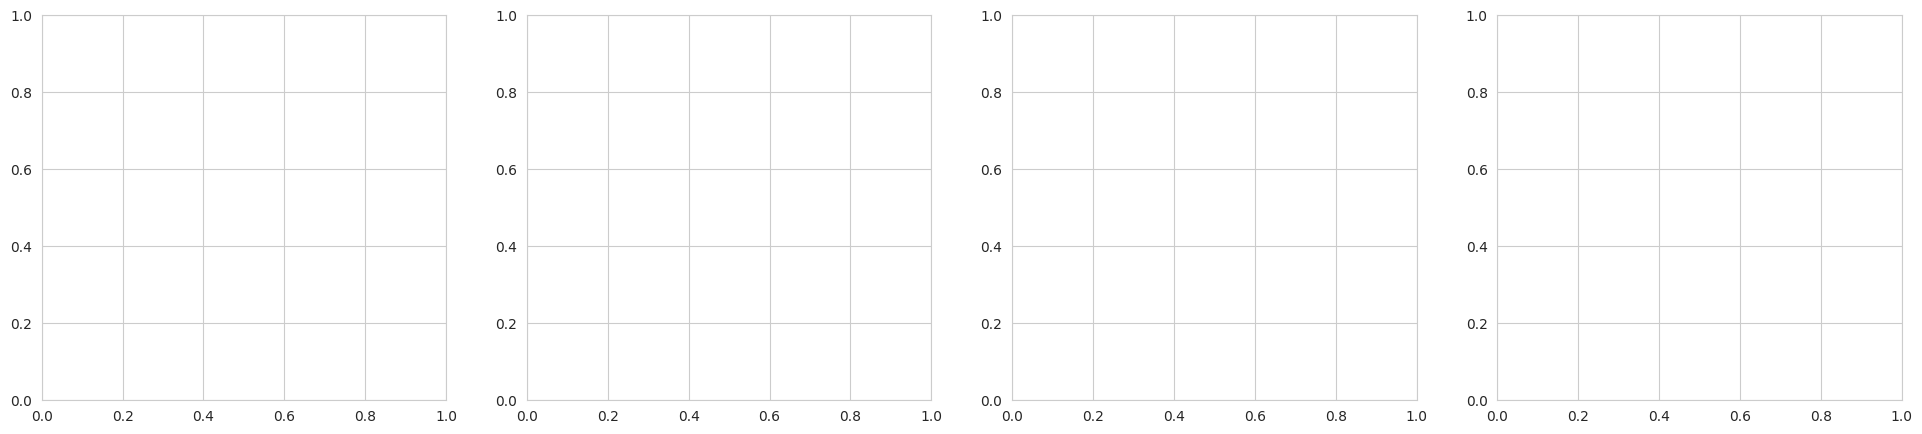

In [10]:
# Create separate plot for each category
output_dir = Path('tenxvisium_plots')
output_dir.mkdir(exist_ok=True)

for category, metrics in metric_categories.items():
    n_metrics = len(metrics)
    
    fig, axes = plt.subplots(1, n_metrics, figsize=(6*n_metrics, 5))
    if n_metrics == 1:
        axes = [axes]
    
    for i, metric_col in enumerate(metrics):
        ax = axes[i]
        
        # Get metric name
        if isinstance(metric_col, tuple):
            metric_name = metric_col[1]
        else:
            metric_name = str(metric_col)
        
        # Prepare data
        plot_data = combined_df[['method_type', 'dataset', metric_col]].copy()
        plot_data.columns = ['Method', 'Dataset', 'Value']
        plot_data = plot_data.dropna(subset=['Value'])
        
        if len(plot_data) > 0:
            # Create boxplot
            sns.boxplot(
                data=plot_data,
                x='Method',
                y='Value',
                order=method_order,
                palette=colors,
                ax=ax,
                width=0.6
            )
            
            # Add individual points
            sns.stripplot(
                data=plot_data,
                x='Method',
                y='Value',
                order=method_order,
                color='black',
                alpha=0.4,
                size=6,
                ax=ax
            )
            
            ax.set_title(metric_name, fontsize=14, fontweight='bold')
            ax.set_xlabel('Method', fontsize=12)
            ax.set_ylabel('Value', fontsize=12)
            ax.tick_params(axis='x', rotation=45)
            
            # Add grid
            ax.yaxis.grid(True, alpha=0.3)
            ax.set_axisbelow(True)
    
    plt.suptitle(f'{category} Metrics', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save
    output_file = output_dir / f'tenxvisium_{category.lower().replace(" ", "_")}.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Saved: {output_file}")
    
    plt.show()

print(f"\nAll plots saved to: {output_dir}")

## Best Performing Method per Metric

In [ ]:
# For each metric, identify which method has highest mean performance
# Note: For some metrics like Geary's C, lower is better

best_methods = []

# Metrics where higher is better
higher_is_better = ['ARI', 'NMI', 'HOM', 'COM', 'PAS', 'ASW', "Moran'I"]
# Metrics where lower is better
lower_is_better = ['CHAOS', "Geary's C"]

for metric_col in metric_cols:
    if isinstance(metric_col, tuple):
        metric_category, metric_name = metric_col
        metric_label = f"{metric_category}_{metric_name}"
    else:
        metric_name = str(metric_col)
        metric_label = metric_name
    
    # Compute mean for each method
    method_means = {}
    for method in method_order:
        values = combined_df[combined_df['method_type'] == method][metric_col].dropna()
        if len(values) > 0:
            method_means[method] = values.mean()
    
    if len(method_means) > 0:
        # Determine best method
        if any(m in metric_name for m in lower_is_better):
            best_method = min(method_means, key=method_means.get)
            direction = 'lower is better'
        else:
            best_method = max(method_means, key=method_means.get)
            direction = 'higher is better'
        
        best_methods.append({
            'Metric': metric_label,
            'Best Method': best_method,
            'Best Value': method_means[best_method],
            'Direction': direction,
            'All Methods': ', '.join([f"{m}: {v:.3f}" for m, v in sorted(method_means.items())])
        })

best_df = pd.DataFrame(best_methods)
print("\nBest performing method for each metric:")
print("="*80)
for _, row in best_df.iterrows():
    print(f"\n{row['Metric']} ({row['Direction']}):")
    print(f"  Winner: {row['Best Method']} ({row['Best Value']:.3f})")
    print(f"  {row['All Methods']}")

# Count wins per method
print("\n" + "="*80)
print("Number of metrics where each method performed best:")
print("="*80)
wins = best_df['Best Method'].value_counts()
for method in method_order:
    count = wins.get(method, 0)
    print(f"  {method}: {count} metrics")